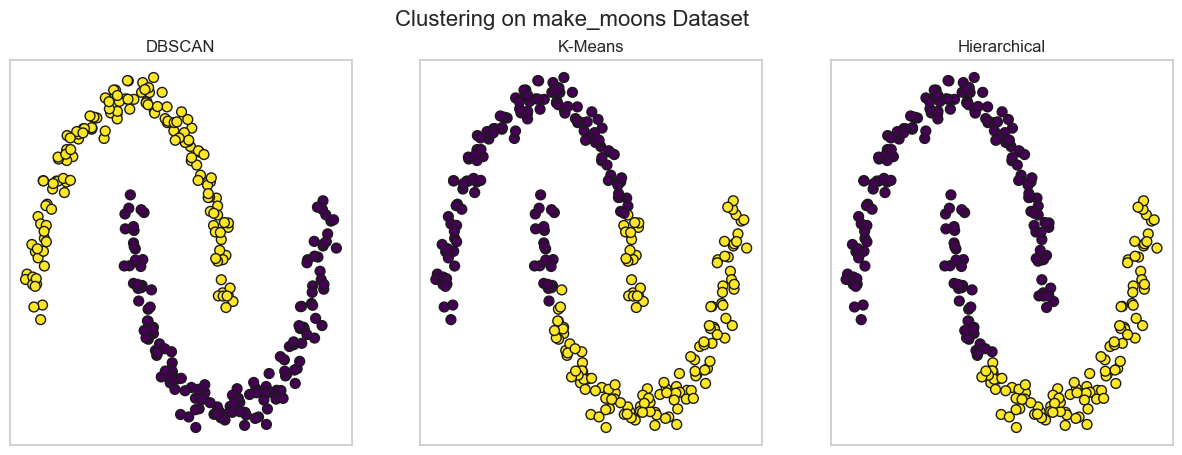

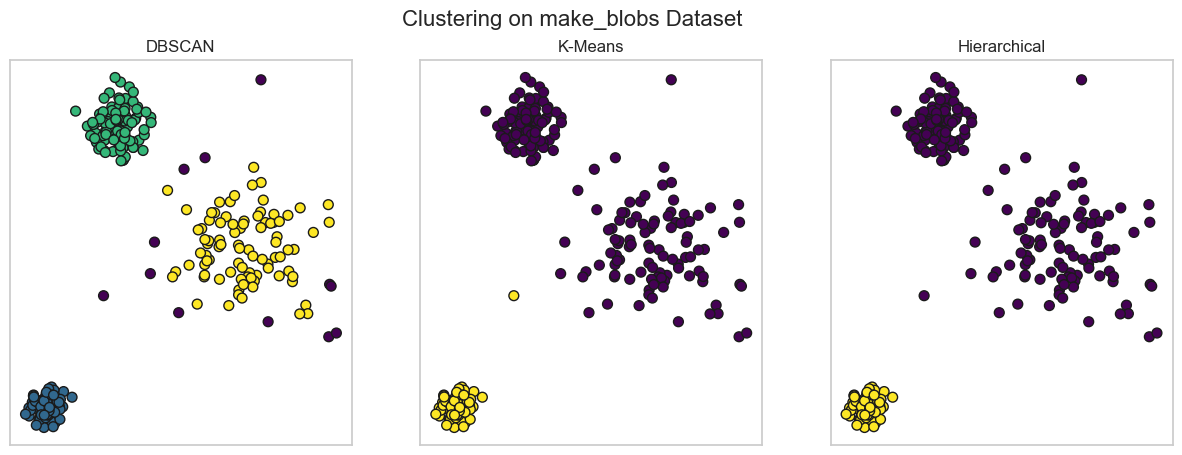

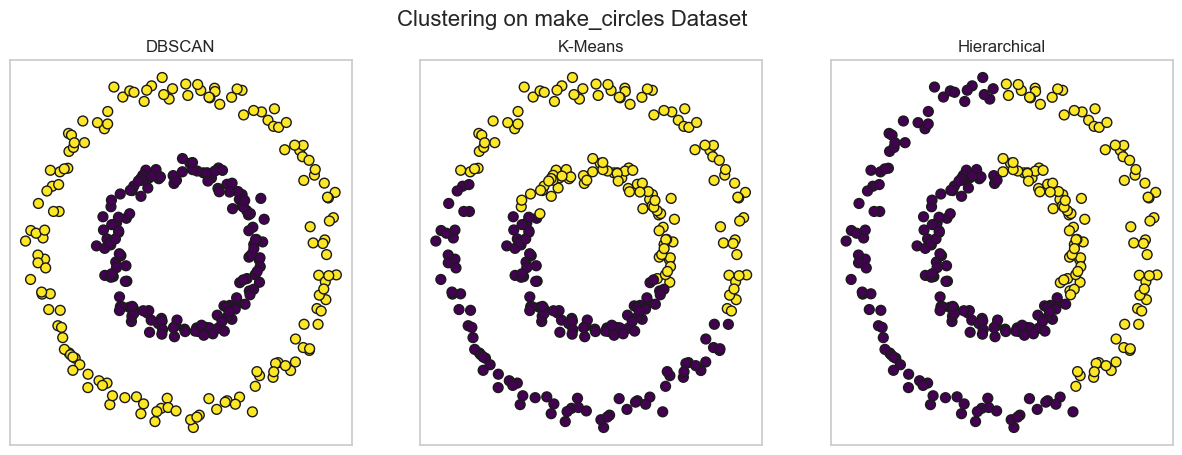

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler

# Set Seaborn style
sns.set(style="whitegrid")

# Generate datasets
X_moons, _ = make_moons(n_samples=300, noise=0.05,random_state=42)
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)
X_circles, _ = make_circles(n_samples=300, factor=0.5, noise=0.05)


# Standardize datasets
X_moons = StandardScaler().fit_transform(X_moons)
X_blobs = StandardScaler().fit_transform(X_blobs)
X_circles = StandardScaler().fit_transform(X_circles)

# Define clustering algorithms
clustering_algorithms = {
    "DBSCAN": DBSCAN(eps=0.3, min_samples=5),
    "K-Means": KMeans(n_clusters=2, random_state=42),
    "Hierarchical": AgglomerativeClustering(n_clusters=2)
}

# Function to plot results
def plot_clusters(X, title, clustering_algorithms):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)

    for ax, (name, algorithm) in zip(axes, clustering_algorithms.items()):
        labels = algorithm.fit_predict(X)
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", edgecolor="k", s=50)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

# Plot clustering results
plot_clusters(X_moons, "Clustering on make_moons Dataset", clustering_algorithms)
plot_clusters(X_blobs, "Clustering on make_blobs Dataset", clustering_algorithms)
plot_clusters(X_circles, "Clustering on make_circles Dataset", clustering_algorithms)